Variables categóricas

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [16]:
plt.rcParams.update({'figure.dpi': 110})


In [17]:
leads = pd.read_csv('Analisis_GAC_Full7agosto_2026_LeadsReales.csv')
leads = leads.iloc[1:].reset_index(drop=True)
leads.columns = ['Año','Mes','Total','Ilocalizable','No_Contesta','D_Incorrectos',
                  'Duplicados','Efectivos','Abiertos','Ventas','Conversion','Efectividad','x1','x2']
leads = leads.drop(columns=['x1','x2'])
leads = leads.dropna(subset=['Mes'])
leads['Mes'] = leads['Mes'].astype(str).str.strip()          # <- quita espacios ("Enero " -> "Enero")
leads = leads[leads['Mes'] != 'Mes']
leads['Año'] = leads['Año'].ffill()
leads = leads.dropna(subset=['Total'])

for c in ['Total','Ilocalizable','No_Contesta','D_Incorrectos','Duplicados','Efectivos','Abiertos','Ventas']:
    leads[c] = pd.to_numeric(leads[c].astype(str).str.replace(',', ''), errors='coerce')
leads['Conversion'] = pd.to_numeric(leads['Conversion'].astype(str).str.replace('%',''), errors='coerce')
leads['Efectividad'] = pd.to_numeric(leads['Efectividad'].astype(str).str.replace('%',''), errors='coerce')
leads = leads[leads['Mes'] != 'Prome.']
leads['Año'] = leads['Año'].astype(int)
leads = leads.reset_index(drop=True)

print("Nulos antes de limpiar:\n", leads.isnull().sum())
leads = leads.dropna()
print("Nulos después de limpiar:\n", leads.isnull().sum())
leads.to_csv('leads_reales_clean.csv', index=False)

# Orden cronológico real de los meses y periodo Mes-Año para no repetir etiquetas
orden_meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio','Agosto',
               'Septiembre','Octubre','Noviembre','Diciembre']
leads['Mes'] = pd.Categorical(leads['Mes'], categories=orden_meses, ordered=True)
leads['Periodo'] = leads['Mes'].astype(str).str[:3] + '-' + leads['Año'].astype(str).str[-2:]

Nulos antes de limpiar:
 Año              0
Mes              0
Total            0
Ilocalizable     0
No_Contesta      0
D_Incorrectos    0
Duplicados       0
Efectivos        0
Abiertos         0
Ventas           0
Conversion       0
Efectividad      0
dtype: int64
Nulos después de limpiar:
 Año              0
Mes              0
Total            0
Ilocalizable     0
No_Contesta      0
D_Incorrectos    0
Duplicados       0
Efectivos        0
Abiertos         0
Ventas           0
Conversion       0
Efectividad      0
dtype: int64


In [18]:
raw = pd.read_csv('Analisis_GAC_Full7agosto_2026_Leads_por_Canal.csv', header=None)
canales = raw.iloc[4:10, [0] + list(range(1, 31))].copy()
canales.columns = ['Canal'] + list(pd.date_range('2024-01-01', periods=30, freq='MS').strftime('%Y-%m'))
canales['Canal'] = canales['Canal'].str.strip()

# --- Tratamiento de valores nulos ---
canales = canales.replace({'-': np.nan})              # guiones = sin dato
for c in canales.columns[1:]:
    canales[c] = pd.to_numeric(canales[c], errors='coerce')
print("Nulos antes de limpiar:", canales.isnull().sum().sum())
canales[canales.columns[1:]] = canales[canales.columns[1:]].fillna(0)  # sin leads ese mes = 0
print("Nulos después de limpiar:", canales.isnull().sum().sum())

leads_canal = canales.melt(id_vars='Canal', var_name='Periodo', value_name='Leads')
leads_canal.to_csv('leads_por_canal_clean.csv', index=False)

Nulos antes de limpiar: 0
Nulos después de limpiar: 0


In [19]:
# Función auxiliar: pone el número exacto arriba de cada barra
def etiquetar_barras(ax):
    for cont in ax.containers:
        ax.bar_label(cont, fontsize=9, padding=2)

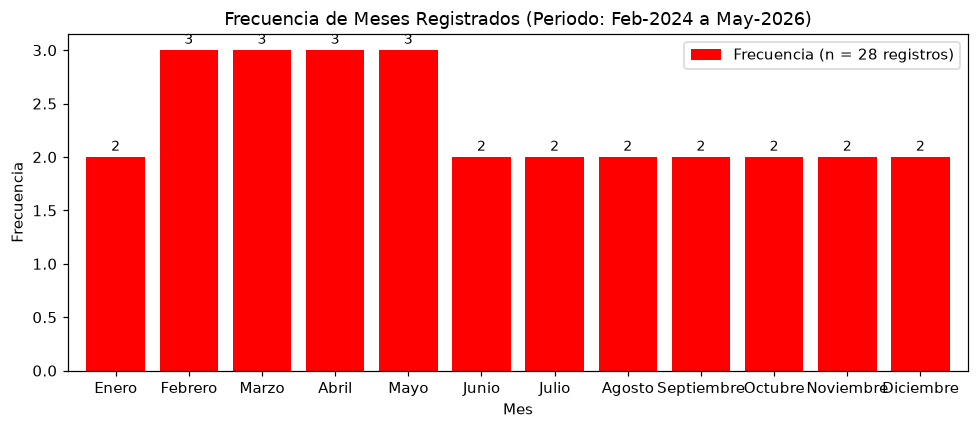

In [20]:
# ---- Gráfica 1: Mes (orden cronológico, con el periodo en el título) ----
Tabla_freq = leads['Mes'].value_counts().reindex(orden_meses).reset_index()
Tabla_freq.columns = ['Mes', 'count']
Filtro_index = Tabla_freq.set_index('Mes')
n_total = int(Filtro_index['count'].sum())
Filtro_index.columns = [f'Frecuencia (n = {n_total} registros)']

ax = Filtro_index.plot(kind='bar', width=0.8, figsize=(9,4), color='red', legend=True, rot=0)
plt.title('Frecuencia de Meses Registrados (Periodo: Feb-2024 a May-2026)')
plt.xlabel('Mes'); plt.ylabel('Frecuencia')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

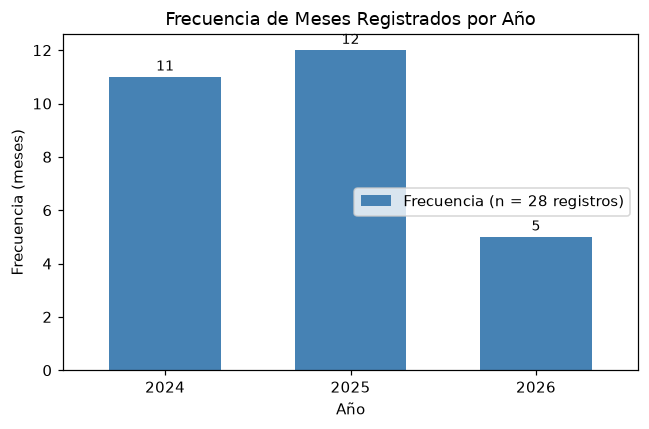

In [22]:
# ---- Gráfica 2: Año (frecuencia de meses registrados por año) ----
Tabla_freq = leads['Año'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Año', 'count']
Filtro_index = Tabla_freq.set_index('Año')
n_total = int(Filtro_index['count'].sum())
Filtro_index.columns = [f'Frecuencia (n = {n_total} registros)']

ax = Filtro_index.plot(kind='bar', width=0.6, color='steelblue', figsize=(6,4), legend=True, rot=0)
plt.title('Frecuencia de Meses Registrados por Año')
plt.xlabel('Año'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

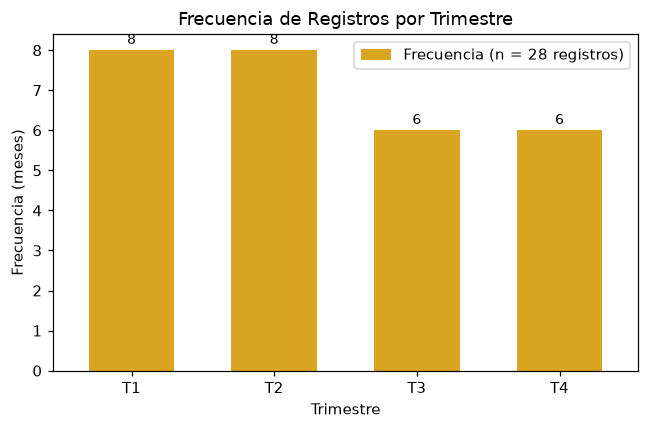

In [23]:
# ---- Gráfica 3: Trimestre (derivada de Mes) ----
mapa_trimestre = {m: f"T{((orden_meses.index(m))//3)+1}" for m in orden_meses}
leads['Trimestre'] = leads['Mes'].astype(str).map(mapa_trimestre)

Tabla_freq = leads['Trimestre'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Trimestre', 'count']
Filtro_index = Tabla_freq.set_index('Trimestre')
n_total = int(Filtro_index['count'].sum())
Filtro_index.columns = [f'Frecuencia (n = {n_total} registros)']

ax = Filtro_index.plot(kind='bar', width=0.6, color='goldenrod', figsize=(6,4), legend=True, rot=0)
plt.title('Frecuencia de Registros por Trimestre')
plt.xlabel('Trimestre'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

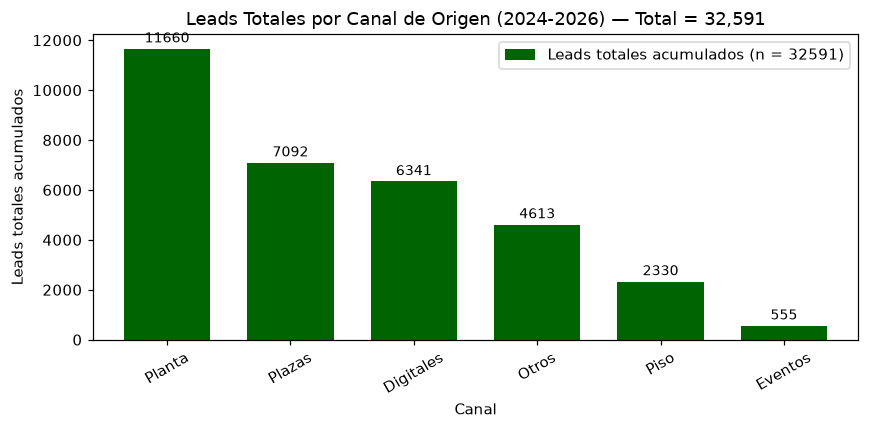

In [24]:
# ---- Gráfica 4: Canal - barras (Leads totales, 2024-2026) ----
Tabla_freq = leads_canal.groupby('Canal')['Leads'].sum().reset_index()
Tabla_freq.columns = ['Canal', 'count']
Filtro_index = Tabla_freq.sort_values('count', ascending=False).set_index('Canal')
n_total = int(Filtro_index['count'].sum())
Filtro_index.columns = [f'Leads totales acumulados (n = {n_total})']

ax = Filtro_index.plot(kind='bar', width=0.7, color='darkgreen', figsize=(8,4), legend=True, rot=30)
plt.title(f'Leads Totales por Canal de Origen (2024-2026) — Total = {n_total:,}')
plt.xlabel('Canal'); plt.ylabel('Leads totales acumulados')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

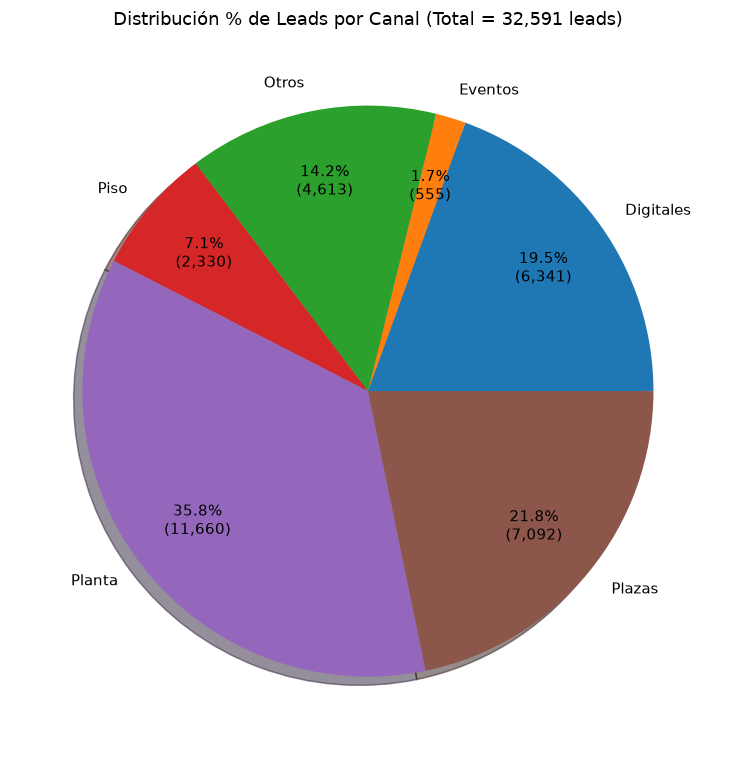

In [25]:
# ---- Gráfica 5: Canal - pastel (% + número debajo, en la etiqueta de afuera) ----
Tabla_freq = Tabla_freq.sort_values('Canal')
total_leads = int(Tabla_freq['count'].sum())

def autopct_con_valor(valores):
    def inner(pct):
        val = int(round(pct/100.*sum(valores)))
        return f'{pct:.1f}%\n({val:,})'
    return inner

fig, ax = plt.subplots(figsize=(7.5,7))
wedges, texts, autotexts = ax.pie(
    Tabla_freq['count'],
    labels=Tabla_freq['Canal'],                       # etiqueta de afuera = nombre del canal
    autopct=autopct_con_valor(Tabla_freq['count']),    # dentro = % y (número) debajo
    shadow=True,
    pctdistance=0.75
)
ax.set_title(f'Distribución % de Leads por Canal (Total = {total_leads:,} leads)')
plt.tight_layout(); plt.show()

Variables numéricas

[Total] n=28, Max=1973, Min=178, R=1795, ni=6, i=299.17


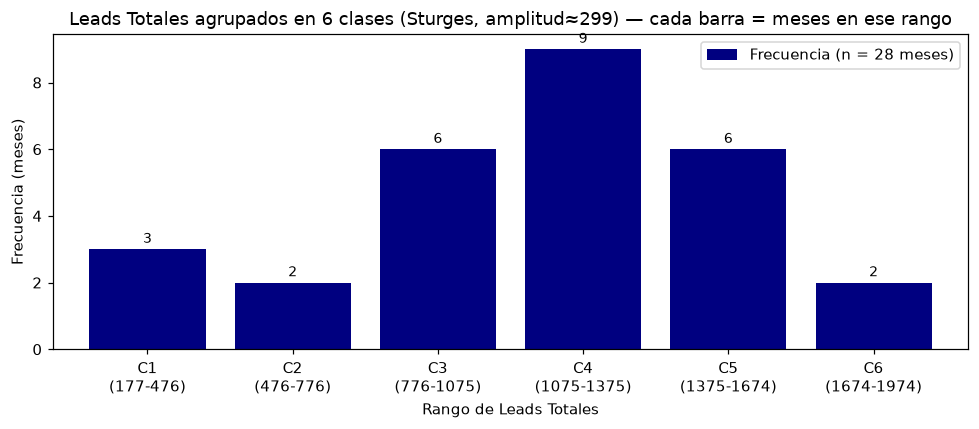

In [26]:
# ¿Qué es la "determinación de clases"? Cuando una variable numérica puede tomar
# muchísimos valores distintos (ej. leads totales: 178, 416, 543, 954...), no tiene
# sentido graficar la frecuencia de cada valor exacto (casi todos aparecerían 1 sola vez).
# Por eso se agrupan los valores en RANGOS o "clases" (ej. 178-476, 477-776, etc.)
# usando la Regla de Sturges, y luego se cuenta cuántos meses cayeron en cada rango.
# Esto es exactamente lo mismo que un histograma, solo que aquí construimos las clases
# manualmente para poder etiquetarlas con su rango real.

# ---- Gráfica 6: Total de leads por mes ----
col = 'Total'
n = leads[col].count()
Max = leads[col].max(); Min = leads[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))          # numero de clases (Sturges)
i = R/ni                                        # amplitud de cada clase
print(f"[{col}] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-1, Max+1, ni+1)
categorias = [f"C{k+1}\n({int(intervalos[k])}-{int(intervalos[k+1])})" for k in range(ni)]
leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)

Tabla_freq = leads[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='navy', figsize=(9,4), legend=True, rot=0)
plt.title(f'Leads Totales agrupados en {ni} clases (Sturges, amplitud≈{round(i)}) — cada barra = meses en ese rango')
plt.xlabel('Rango de Leads Totales'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

n=29, Max=41, Min=6, R=35, ni=6, i=5.83


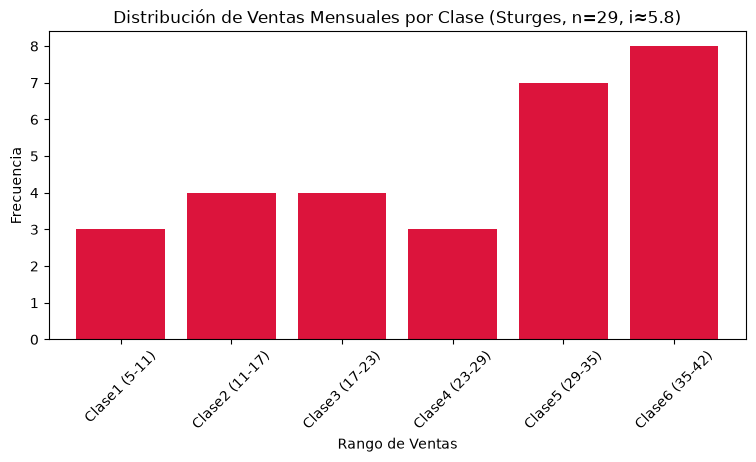

In [ ]:
# ---- Gráfica 7: Ventas mensuales ----
# Igual que en la gráfica anterior: agrupamos los meses según cuántas ventas tuvieron,
# para ver si la mayoría de los meses vende "poco", "medio" o "mucho", en vez de ver
# 28 barras individuales (una por mes) que serían difíciles de comparar.
col = 'Ventas'
n = leads[col].count()
Max = leads[col].max(); Min = leads[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
i = R/ni
print(f"[{col}] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-1, Max+1, ni+1)
categorias = [f"C{k+1}\n({int(intervalos[k])}-{int(intervalos[k+1])})" for k in range(ni)]
leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)

Tabla_freq = leads[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='crimson', figsize=(9,4), legend=True, rot=0)
plt.title(f'Ventas Mensuales agrupadas en {ni} clases (Sturges, amplitud≈{round(i,1)}) — cada barra = meses en ese rango')
plt.xlabel('Rango de Ventas Mensuales'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

[Efectivos] n=28, Max=1040, Min=128, R=912, ni=6, i=152.0


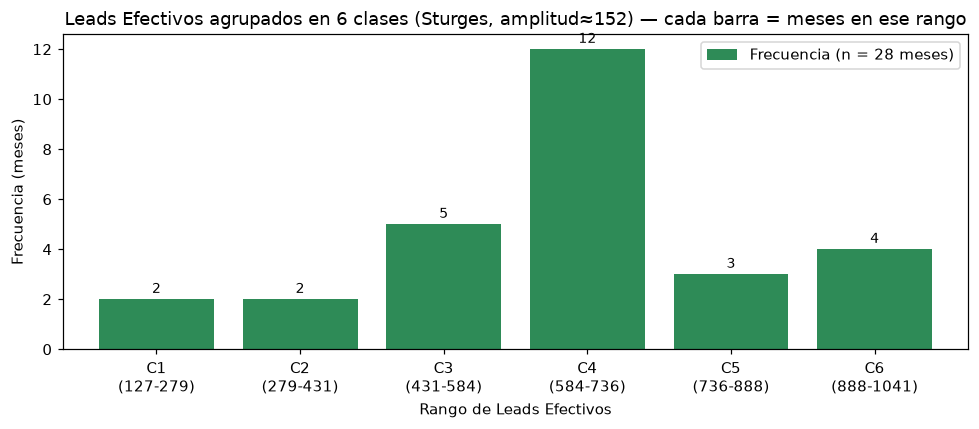

In [27]:
# ---- Gráfica 8: Efectivos ----
col = 'Efectivos'
n = leads[col].count()
Max = leads[col].max(); Min = leads[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
i = R/ni
print(f"[{col}] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-1, Max+1, ni+1)
categorias = [f"C{k+1}\n({int(intervalos[k])}-{int(intervalos[k+1])})" for k in range(ni)]
leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)

Tabla_freq = leads[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='seagreen', figsize=(9,4), legend=True, rot=0)
plt.title(f'Leads Efectivos agrupados en {ni} clases (Sturges, amplitud≈{round(i)}) — cada barra = meses en ese rango')
plt.xlabel('Rango de Leads Efectivos'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

[Conversion] n=28, Max=5.9, Min=1.0, R=4.9, ni=6


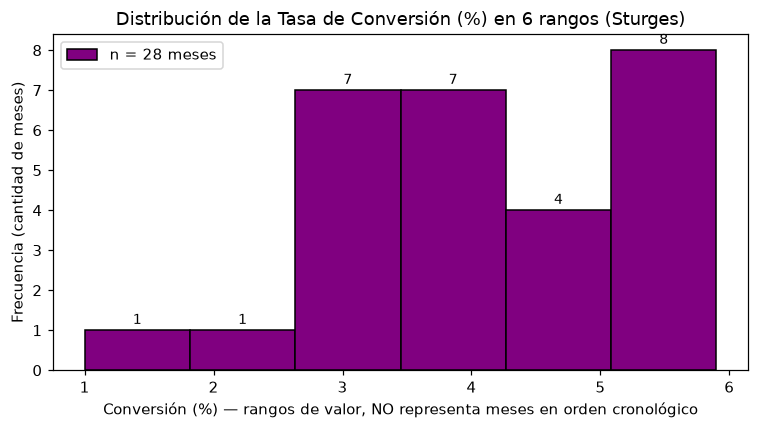

   Periodo  Conversion Conversion_clase
4   Jun-24         1.0   (0.995, 1.817]
9   Nov-24         2.1   (1.817, 2.633]
8   Oct-24         2.8    (2.633, 3.45]
2   Abr-24         2.8    (2.633, 3.45]
6   Ago-24         3.1    (2.633, 3.45]
0   Feb-24         3.1    (2.633, 3.45]
7   Sep-24         3.2    (2.633, 3.45]
10  Dic-24         3.3    (2.633, 3.45]
14  Abr-25         3.4    (2.633, 3.45]
11  Ene-25         3.6    (3.45, 4.267]
5   Jul-24         3.7    (3.45, 4.267]
17  Jul-25         4.0    (3.45, 4.267]
18  Ago-25         4.0    (3.45, 4.267]
25  Mar-26         4.0    (3.45, 4.267]
24  Feb-26         4.1    (3.45, 4.267]
13  Mar-25         4.1    (3.45, 4.267]
12  Feb-25         4.3   (4.267, 5.083]
22  Dic-25         4.7   (4.267, 5.083]
3   May-24         4.7   (4.267, 5.083]
27  May-26         4.8   (4.267, 5.083]
23  Ene-26         5.2     (5.083, 5.9]
1   Mar-24         5.5     (5.083, 5.9]
21  Nov-25         5.5     (5.083, 5.9]
26  Abr-26         5.7     (5.083, 5.9]


In [28]:
# ---- Gráfica 9: Conversión % - histograma ----
# IMPORTANTE: este histograma NO está ordenado por mes ni por tiempo.
# El eje X son RANGOS de porcentaje de conversión (ej. 3%-4%), y la altura de la barra
# dice CUÁNTOS meses (de cualquier año) tuvieron una conversión dentro de ese rango.
# Si quieres saber exactamente qué mes cayó en qué rango, revisa la tabla impresa abajo.
col = 'Conversion'
n = leads[col].count()
Max = leads[col].max(); Min = leads[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
print(f"[{col}] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}")

fig, ax = plt.subplots(figsize=(7,4))
counts, bins, patches = ax.hist(leads[col], bins=ni, color='purple', edgecolor='black',
                                 label=f'n = {n} meses')
ax.bar_label(patches, labels=[int(c) for c in counts], padding=2, fontsize=9)
ax.set_title(f'Distribución de la Tasa de Conversión (%) en {ni} rangos (Sturges)')
ax.set_xlabel('Conversión (%) — rangos de valor, NO representa meses en orden cronológico')
ax.set_ylabel('Frecuencia (cantidad de meses)')
ax.legend()
plt.tight_layout(); plt.show()

# Tabla de referencia: qué mes cayó en qué clase de conversión
leads['Conversion_clase'] = pd.cut(leads['Conversion'], bins=ni)
print(leads[['Periodo','Conversion','Conversion_clase']].sort_values('Conversion'))

[Leads por Canal-Mes] n=180, Max=1214, Min=0, R=1214, ni=8


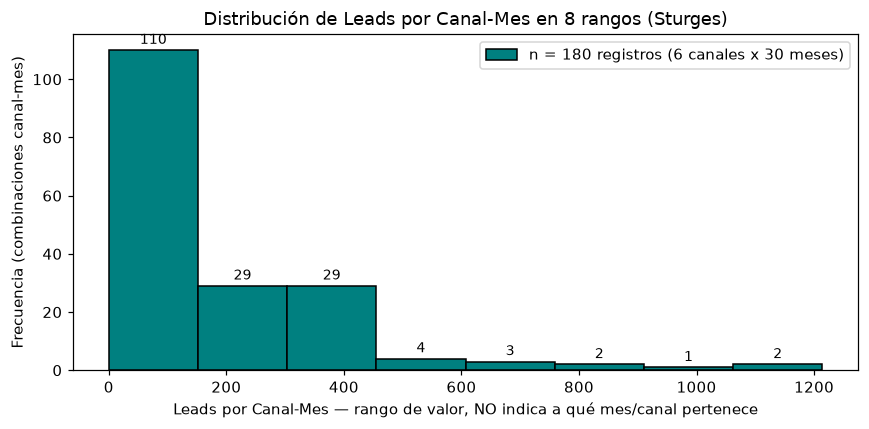

         Canal  Periodo  Leads        Leads_clase
57      Planta  2024-10   1214  (1062.25, 1214.0]
63      Planta  2024-11   1098  (1062.25, 1214.0]
51      Planta  2024-09   1030   (910.5, 1062.25]
47       Otros  2024-08    887    (758.75, 910.5]
69      Planta  2024-12    772    (758.75, 910.5]
159     Planta  2026-03    673    (607.0, 758.75]
75      Planta  2025-01    654    (607.0, 758.75]
118  Digitales  2025-08    625    (607.0, 758.75]
59       Otros  2024-10    518    (455.25, 607.0]
93      Planta  2025-04    495    (455.25, 607.0]


In [29]:
# ---- Gráfica 10: Leads por Canal-Mes - histograma ----
# Igual que la anterior: aquí NO se distingue canal ni mes específico. Se juntan las
# 180 combinaciones (6 canales x 30 meses) y se agrupan según su magnitud de leads,
# para ver qué tan comunes son los meses "bajos" (0-150 leads) vs los meses "altos".
n = leads_canal['Leads'].count()
Max = leads_canal['Leads'].max(); Min = leads_canal['Leads'].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
print(f"[Leads por Canal-Mes] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}")

fig, ax = plt.subplots(figsize=(8,4))
counts, bins, patches = ax.hist(leads_canal['Leads'], bins=ni, color='teal', edgecolor='black',
                                 label=f'n = {n} registros (6 canales x 30 meses)')
ax.bar_label(patches, labels=[int(c) for c in counts], padding=2, fontsize=9)
ax.set_title(f'Distribución de Leads por Canal-Mes en {ni} rangos (Sturges)')
ax.set_xlabel('Leads por Canal-Mes — rango de valor, NO indica a qué mes/canal pertenece')
ax.set_ylabel('Frecuencia (combinaciones canal-mes)')
ax.legend()
plt.tight_layout(); plt.show()

# Tabla de referencia: qué canal/mes tiene los valores más altos
leads_canal['Leads_clase'] = pd.cut(leads_canal['Leads'], bins=ni)
print(leads_canal.sort_values('Leads', ascending=False).head(10))

In [30]:
def tabla_de_referencia(df, col, ni=None):
    """
    Muestra qué mes (Periodo) cae en cada clase/rango de la variable numérica 'col'.
    Si no se pasa 'ni', lo calcula con la Regla de Sturges.
    """
    n = df[col].count()
    Max = df[col].max(); Min = df[col].min()
    R = Max - Min
    if ni is None:
        ni = int(round(1 + 3.32*np.log10(n)))
    i = R/ni

    intervalos = np.linspace(Min-1, Max+1, ni+1)
    categorias = [f"C{k+1} ({round(intervalos[k],1)}-{round(intervalos[k+1],1)})" for k in range(ni)]
    df[f'{col}_clase'] = pd.cut(df[col], bins=intervalos, labels=categorias)

    tabla = df[['Periodo', col, f'{col}_clase']].sort_values(col)
    print(f"--- {col}: {ni} clases, amplitud≈{round(i,2)} ---")
    display(tabla)   # en Colab, display() la muestra como tabla bonita
    return tabla

# Úsalo así para cada variable numérica:
tabla_de_referencia(leads, 'Total')
tabla_de_referencia(leads, 'Ventas')
tabla_de_referencia(leads, 'Efectivos')
tabla_de_referencia(leads, 'Conversion')

--- Total: 6 clases, amplitud≈299.17 ---


,Periodo,Total,Total_clase
1,Mar-24,178,C1 (177.0-476.5)
2,Abr-24,416,C1 (177.0-476.5)
3,May-24,422,C1 (177.0-476.5)
0,Feb-24,543,C2 (476.5-776.0)
12,Feb-25,561,C2 (476.5-776.0)
15,May-25,815,C3 (776.0-1075.5)
13,Mar-25,925,C3 (776.0-1075.5)
5,Jul-24,954,C3 (776.0-1075.5)
4,Jun-24,967,C3 (776.0-1075.5)
11,Ene-25,1042,C3 (776.0-1075.5)


--- Ventas: 6 clases, amplitud≈5.83 ---


,Periodo,Ventas,Ventas_clase
4,Jun-24,6,C1 (5.0-11.2)
1,Mar-24,7,C1 (5.0-11.2)
2,Abr-24,8,C1 (5.0-11.2)
0,Feb-24,12,C2 (11.2-17.3)
3,May-24,13,C2 (11.2-17.3)
6,Ago-24,17,C2 (11.2-17.3)
7,Sep-24,17,C2 (11.2-17.3)
12,Feb-25,20,C3 (17.3-23.5)
5,Jul-24,21,C3 (17.3-23.5)
9,Nov-24,22,C3 (17.3-23.5)


--- Efectivos: 6 clases, amplitud≈152.0 ---


,Periodo,Efectivos,Efectivos_clase
1,Mar-24,128,C1 (127.0-279.3)
3,May-24,274,C1 (127.0-279.3)
2,Abr-24,288,C2 (279.3-431.7)
0,Feb-24,389,C2 (279.3-431.7)
12,Feb-25,468,C3 (431.7-584.0)
7,Sep-24,530,C3 (431.7-584.0)
6,Ago-24,546,C3 (431.7-584.0)
5,Jul-24,570,C3 (431.7-584.0)
15,May-25,574,C3 (431.7-584.0)
4,Jun-24,620,C4 (584.0-736.3)


--- Conversion: 6 clases, amplitud≈0.82 ---


,Periodo,Conversion,Conversion_clase
4,Jun-24,1.0,C1 (0.0-1.2)
9,Nov-24,2.1,C2 (1.2-2.3)
8,Oct-24,2.8,C3 (2.3-3.4)
2,Abr-24,2.8,C3 (2.3-3.4)
6,Ago-24,3.1,C3 (2.3-3.4)
0,Feb-24,3.1,C3 (2.3-3.4)
7,Sep-24,3.2,C3 (2.3-3.4)
10,Dic-24,3.3,C3 (2.3-3.4)
14,Abr-25,3.4,C3 (2.3-3.4)
11,Ene-25,3.6,C4 (3.4-4.6)


,Periodo,Conversion,Conversion_clase
4,Jun-24,1.0,C1 (0.0-1.2)
9,Nov-24,2.1,C2 (1.2-2.3)
8,Oct-24,2.8,C3 (2.3-3.4)
2,Abr-24,2.8,C3 (2.3-3.4)
6,Ago-24,3.1,C3 (2.3-3.4)
0,Feb-24,3.1,C3 (2.3-3.4)
7,Sep-24,3.2,C3 (2.3-3.4)
10,Dic-24,3.3,C3 (2.3-3.4)
14,Abr-25,3.4,C3 (2.3-3.4)
11,Ene-25,3.6,C4 (3.4-4.6)


In [31]:
n = leads_canal['Leads'].count()
ni = int(round(1 + 3.32*np.log10(n)))
leads_canal['Leads_clase'] = pd.cut(leads_canal['Leads'], bins=ni)

print("--- Top 15 combinaciones Canal-Mes con más leads ---")
display(leads_canal.sort_values('Leads', ascending=False).head(15)[['Canal','Periodo','Leads','Leads_clase']])

print("\n--- Cuántos registros cayeron en cada clase ---")
display(leads_canal['Leads_clase'].value_counts().sort_index())

--- Top 15 combinaciones Canal-Mes con más leads ---


,Canal,Periodo,Leads,Leads_clase
57,Planta,2024-10,1214,"(1062.25, 1214.0]"
63,Planta,2024-11,1098,"(1062.25, 1214.0]"
51,Planta,2024-09,1030,"(910.5, 1062.25]"
47,Otros,2024-08,887,"(758.75, 910.5]"
69,Planta,2024-12,772,"(758.75, 910.5]"
159,Planta,2026-03,673,"(607.0, 758.75]"
75,Planta,2025-01,654,"(607.0, 758.75]"
118,Digitales,2025-08,625,"(607.0, 758.75]"
59,Otros,2024-10,518,"(455.25, 607.0]"
93,Planta,2025-04,495,"(455.25, 607.0]"



--- Cuántos registros cayeron en cada clase ---


Leads_clase
(-1.214, 151.75]     110
(151.75, 303.5]       29
(303.5, 455.25]       29
(455.25, 607.0]        4
(607.0, 758.75]        3
(758.75, 910.5]        2
(910.5, 1062.25]       1
(1062.25, 1214.0]      2
Name: count, dtype: int64